In [ ]:
## Time Series
- Salah satu contoh Case dari Model Regresi
- Cirinya dia memiliki Kolom waktu (Time) yg berurutan dan lengkap
- Istilah yg biasa digunakan untuk Prediksi --> Forecasting
- Biasanya lebih dari satuan waktu
    - Misalkan, forecasting 4 bulan kedepan
- Time series ==> 1 Kolom Features ==> Waktu, dan 1 kolom target

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("shampo sales.csv")
df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


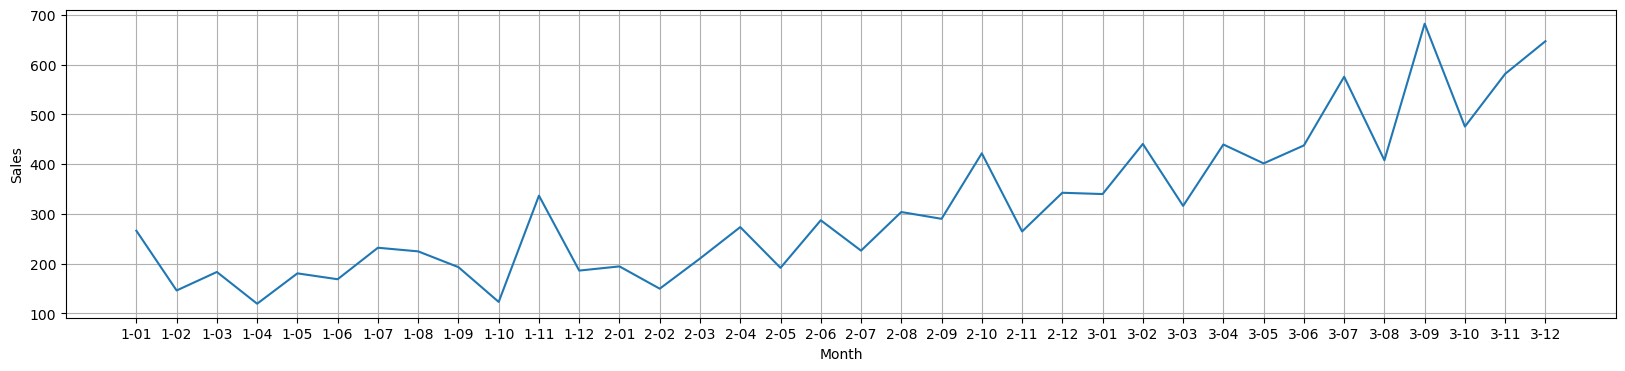

In [9]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=df, x = 'Month', y = 'Sales')
plt.grid(True)
plt.show()

In [ ]:
##  Datanya belum stasioner
## kalau mau pake ARIMA, harus dilakukan differencing (transform agar stasioner)

## Dataset Splitting

In [11]:
## Splitting TIDAK BOLEH RANDOM
## Test set kita tentukan beberapa bulan terakhir

In [12]:
train = df.iloc[:30]
test = df.iloc[30:]

In [13]:
## Cek Stationarity dengan adfuller test

## Hipotesis :
Ho : Data tidak stationer
Ha : Data Stationer

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
adfuller(train['Sales'])

(0.4873059070996327,
 0.9844821197389603,
 3,
 26,
 {'1%': -3.7112123008648155,
  '5%': -2.981246804733728,
  '10%': -2.6300945562130176},
 223.37243316548202)

In [17]:
## Cek stationarity
pval = adfuller(train['Sales'])[1]
pval

0.9844821197389603

In [18]:
## pvalue > 0.05 --> Fail to reject Ho --> Data tidak stationer
## perlu melakukan Differencing

In [21]:
train['Sales'].diff() ## differencing, default nya 1

0       NaN
1    -120.1
2      37.2
3     -63.8
4      61.0
5     -11.8
6      63.3
7      -7.3
8     -31.7
9     -69.9
10    213.6
11   -150.6
12      8.4
13    -44.8
14     60.6
15     63.2
16    -81.9
17     95.6
18    -61.0
19     77.6
20    -13.7
21    131.7
22   -157.1
23     77.8
24     -2.6
25    100.7
26   -124.5
27    123.4
28    -38.0
29     36.1
Name: Sales, dtype: float64

In [22]:
## Cek stationer setelah differencing
pval_dif1 = adfuller(train['Sales'].diff().dropna())[1]
pval_dif1

1.7390606693039065e-08

In [23]:
## pval < 0.05 --> reject Ho --> Data stationer

In [25]:
## ACF - PACF
## Salah satu metode untuk menentukan Hyperparameter untuk model ARIMA(p, d, q)

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

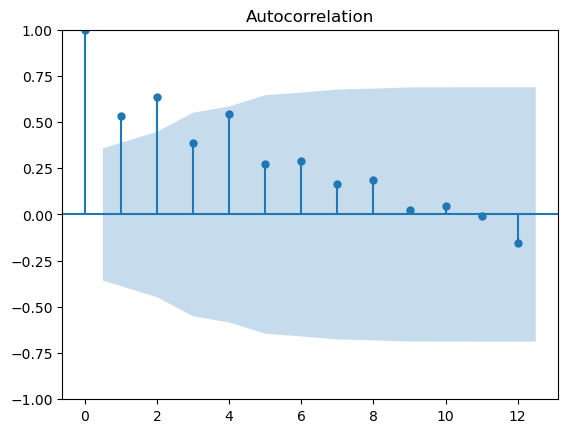

In [28]:
plot_acf(train['Sales'], lags=12);

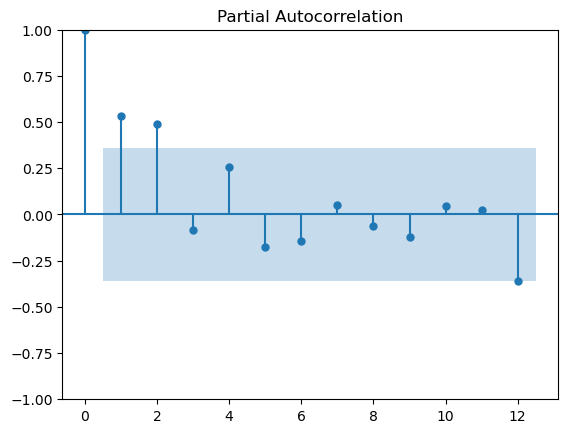

In [29]:
plot_pacf(train['Sales'], lags=12);

In [31]:
train['Sales_diff1'] = train['Sales'].diff()
train['Sales_diff2'] = train['Sales'].diff(2)

In [32]:
train.head()

,Month,Sales,Sales_diff1,Sales_diff2
0,1-01,266.0,NaN,NaN
1,1-02,145.9,-120.1,NaN
2,1-03,183.1,37.2,-82.9
3,1-04,119.3,-63.8,-26.6
4,1-05,180.3,61.0,-2.8


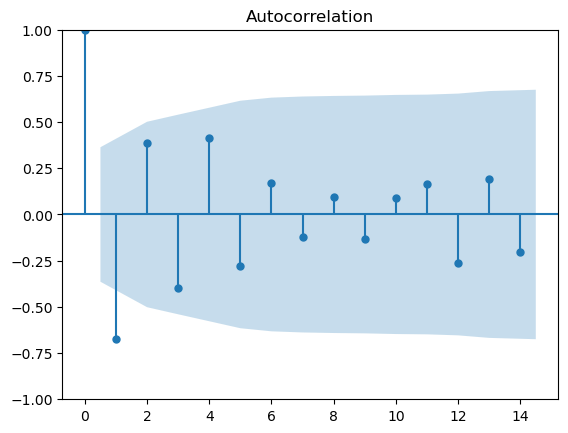

In [35]:
plot_acf(train['Sales_diff1'].dropna(), lags=14);

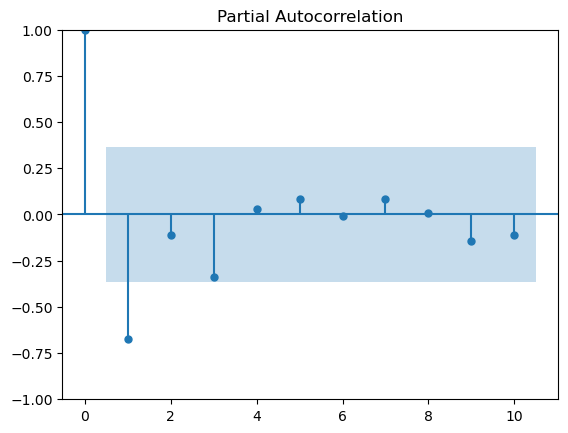

In [37]:
plot_pacf(train['Sales_diff1'].dropna(), lags=10);

In [ ]:
## Summary
- Dataset belum stationer, lineplot punya pattern dan grafik ACF/PACF menurun perlahan
- Sehingga kita perlu melakukan Differencing agar data stationer
- Kita coba differencing 1 dan hasil test adfuller ==> Stationer
- Setelah data stationer, kita cek lagi grafik PACF/ACF
- Hasilnya : grafik PACF cutoff setelah lags 1
- Grafik ACF tailf Off (tidak ada beda signifikan)
sehingga yg parameter yg cocok berdasarkan grafik ACF/PACF
nilai 
- AR : 1 ==> Based on PACF cutoff
- I : 1 ==> Differencing 1 sudah bisa stationer
- MA : 0  ==> NIlai ACF nya tails Off
- Jadi kita pake ARIMA(1, 1, 0)

In [38]:
## Modelling

In [40]:
from statsmodels.tsa.arima.model import ARIMA

In [41]:
## define model
arima_110 = ARIMA(train['Sales'], order=(1,1,0))

In [42]:
## fit - train model
arima_110_fit = arima_110.fit()

In [43]:
## eva metrics
## AIC score ==> Akaike Information Criterion ==> menilai seberapa baik suatu model stats => ARIMA cocok dg data.

In [45]:
arima_110_fit.aic
## semakin kecil nilai AIC, semakin bagus modelnya

328.8048334431185

In [46]:
## Forecast
## Prediksi sales 6 bulan kedepan

In [47]:
## prediksi berapa bula kedepan
Length = 6

## forecast
forecast_result = arima_110_fit.forecast(Length)

In [48]:
forecast_result

30    412.657884
31    429.615566
32    417.993158
33    425.958891
34    420.499359
35    424.241197
Name: predicted_mean, dtype: float64

In [49]:
from sklearn.metrics import mean_absolute_error

In [50]:
## MAE
mean_absolute_error(test['Sales'], forecast_result)

146.94417941007296

In [51]:
df['forecast_sales'] = forecast_result

In [54]:
df.tail(6)

,Month,Sales,forecast_sales
30,3-07,575.5,412.657884
31,3-08,407.6,429.615566
32,3-09,682.0,417.993158
33,3-10,475.3,425.958891
34,3-11,581.3,420.499359
35,3-12,646.9,424.241197


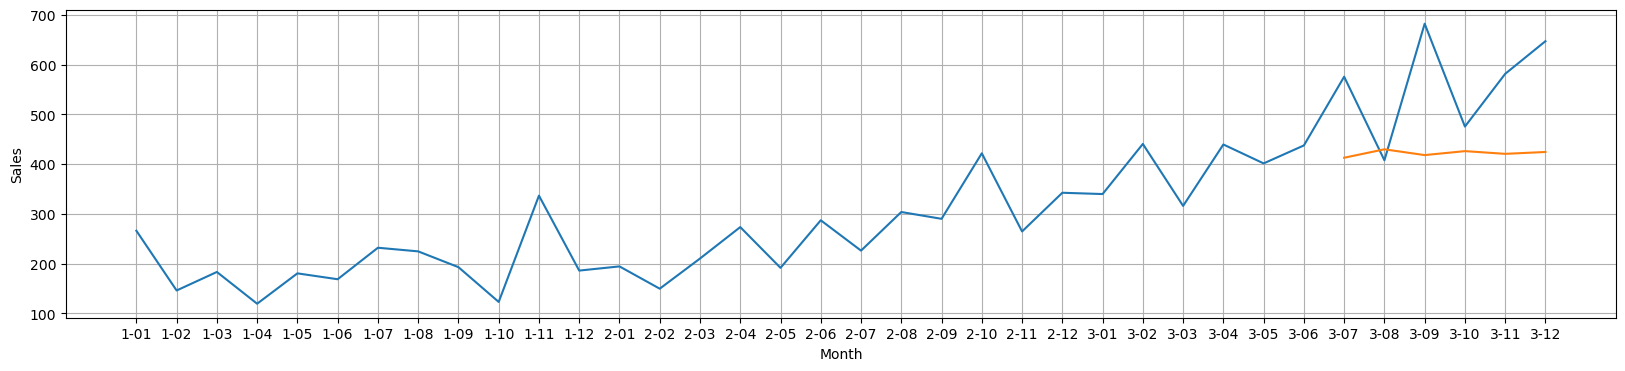

In [56]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=df, x = 'Month', y = 'Sales')
sns.lineplot(data=df, x = 'Month', y = 'forecast_sales')
plt.grid(True)
plt.show()

In [57]:
## Tuning Manual

In [58]:
MAE_score = []
pdq = []
for p in range(2,11):
    for d in range(0,1):
        for q in range(2,9):
            ##define model
            arima = ARIMA(train['Sales'], order=(p,d,q))
            arima_fit = arima.fit()
            
            ## prediksi 6 bulan
            Length = 6
            forecast = arima_fit.forecast(Length)
            mae = mean_absolute_error(test['Sales'], forecast)
            MAE_score.append(mae)
            pdq.append([p,d,q])

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

LinAlgError: LU decomposition error.

In [59]:
data = {"pdq" : pdq,
       "MAE" : MAE_score}
df_mae = pd.DataFrame(data)

In [60]:
df_mae.sort_values("MAE").head()

,pdq,MAE
19,"[4, 0, 7]",90.744995
53,"[9, 0, 6]",93.281775
54,"[9, 0, 7]",107.335348
5,"[2, 0, 7]",111.680453
44,"[8, 0, 4]",116.853068


In [61]:
## derfine Model
arima_906 = ARIMA(train['Sales'], order=(9,0,6))
arima_906_fit = arima_906.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [62]:
## derfine Model
arima_407 = ARIMA(train['Sales'], order=(4,0,7))
arima_407_fit = arima_407.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [63]:
forecast_906 = arima_906_fit.forecast(Length)
forecast_407 = arima_407_fit.forecast(Length)

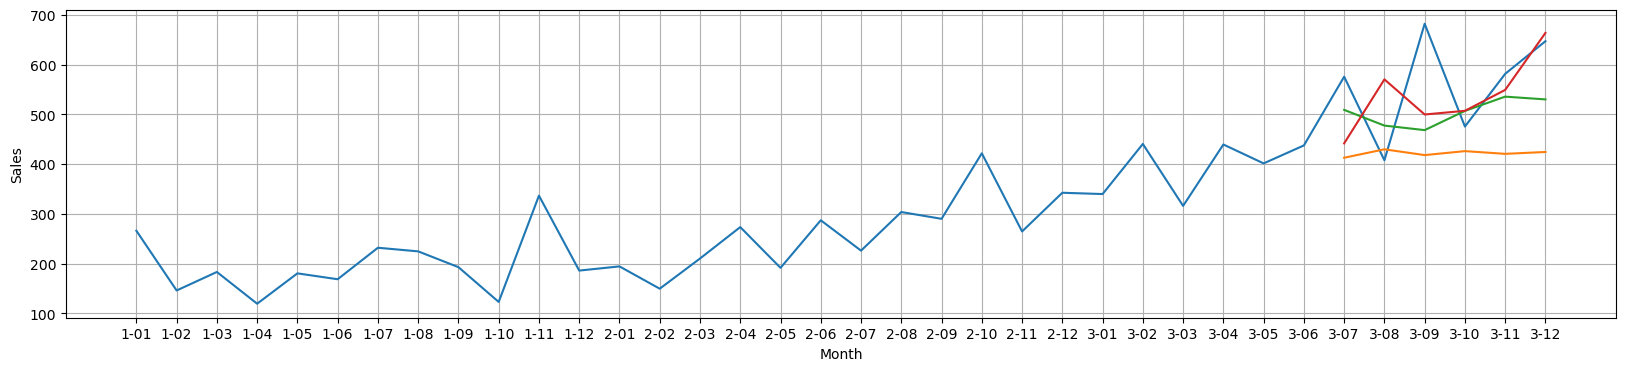

In [65]:
plt.figure(figsize=(20, 4))
sns.lineplot(data=df, x = 'Month', y = 'Sales')
sns.lineplot(data=df, x = 'Month', y = 'forecast_sales')
sns.lineplot(data=df, x = 'Month', y = forecast_407)
sns.lineplot(data=df, x = 'Month', y = forecast_906)
plt.grid(True)
plt.show()